In [2]:
import pandas as pd
import numpy as np
import os
import pickle
from numpy.random import default_rng
import pyarrow.csv as pv
from tqdm import tqdm
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#import tensorflow as tf
#from tensorflow.keras import layers, Model
from numpy import *

from sklearn.tree import BaseDecisionTree
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from operator import itemgetter
from multiprocessing import Pool


import scanpy as sc
import anndata
import decoupler as dc
# Plotting options, change to your liking
sc.settings.set_figure_params(dpi=900, frameon=False)
sc.set_figure_params(dpi=900)
sc.set_figure_params(figsize=(6, 6))


# infer transcriptional factor activities individually

In [6]:
net = dc.get_collectri(organism='human', split_complexes=False)

In [ ]:
folder_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Data/Individuals/'
adata_files = os.listdir(folder_path)
for i in range(len(adata_files)):
    print(i)
    filename = adata_files[i]
    sample_name = filename.split('.h5ad')[0]
    read_path = folder_path + filename
    adata = sc.read_h5ad(read_path)
    
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)

    # Annotate the group of mitochondrial genes as 'mt'
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

    # Filter cells following standard QC criteria.
    adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
    adata = adata[adata.obs.pct_counts_mt < 5, :].copy()
    
    try:
        # Normalize the data
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        adata.layers['log_norm'] = adata.X.copy()
    
        # Identify the highly variable genes
        sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

        # Regress and scale the data
        sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
        sc.pp.scale(adata, max_value=10)

        # Generate PCA features
        sc.tl.pca(adata, svd_solver='arpack')

        # Restore X to be norm counts
        dc.swap_layer(adata, 'log_norm', X_layer_key=None, inplace=True)

        # Compute distances in the PCA space, and find cell neighbors
        sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

        # Generate UMAP features
        sc.tl.umap(adata)

        # Run leiden clustering algorithm
        sc.tl.leiden(adata, flavor='igraph', n_iterations=2, directed=False)
        adata.raw = adata.copy()
    
        dc.run_ulm(
        mat=adata,
        net=net,
        source='source',
        target='target',
        weight='weight',
        min_n=5,
        verbose=True,
        use_raw=True)
    
        acts = dc.get_acts(adata, obsm_key='ulm_estimate')
        df = dc.rank_sources_groups(acts, groupby='class', method='t-test_overestim_var')
    
        save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_outputs/' + sample_name + '.csv' 
        df.to_csv(save_path)
    except:
        print(sample_name , "infeasible")

In [ ]:
TF_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_outputs/'
TF_files = os.listdir(TF_folder)

HPA_neuron = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Refinement/Metabolomics/HPA_Neuron_Genes.csv')
HPA_neuron_EN = HPA_neuron[HPA_neuron['Single Cell Type RNA - Excitatory neurons [nTPM]']>0]
HPA_neuron_EN = set(HPA_neuron_EN['Gene'].to_list())

HPA_neuron_IN = HPA_neuron[HPA_neuron['Single Cell Type RNA - Inhibitory neurons [nTPM]']>0]
HPA_neuron_IN = set(HPA_neuron_IN['Gene'].to_list())

overlap_TF_EN = []
overlap_TF_IN = []

for i in tqdm(TF_files, desc="Processing items"):
    read_path = TF_folder + i
    TF = pd.read_csv(read_path, index_col=0)
    TF_EN = TF[TF['group'].isin(['EN'])]
    TF_IN = TF[TF['group'].isin(['IN'])]

    TF_EN = set(TF_EN['names'].to_list())
    TF_IN = set(TF_IN['names'].to_list())

    num_TF_EN = len(HPA_neuron_EN & TF_EN)
    num_TF_IN = len(HPA_neuron_IN & TF_IN)

    overlap_TF_EN.append(num_TF_EN)
    overlap_TF_IN.append(num_TF_IN)


In [ ]:
summzry_df = pd.DataFrame({"Sample": TF_files, 
                           "EN_TF": overlap_TF_EN,
                           "IN_TF": overlap_TF_IN})
summzry_df.to_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/TF_summaty_IN_EN.xlsx')

# infer transcriptional factor activities per group 

In [2]:
NPS_AD_metadata = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/NPS-AD_neuropathology_and_diagnosis_metadata.csv')
NPS_AD_metadata = NPS_AD_metadata.rename(columns={'IndividualID': 'Individual_ID'})
NPS_AD_metadata = NPS_AD_metadata[['Individual_ID', 'BRAAK_AD']]
NPS_AD_metadata_conditional = NPS_AD_metadata[['Individual_ID', 'BRAAK_AD']]

NPS_AD_metadata

,Individual_ID,BRAAK_AD
0,AMPAD_MSSM_0000029668,2.0
1,AMPAD_MSSM_00000M1061,0.0
2,AMPAD_MSSM_00000M1062,0.0
3,AMPAD_MSSM_0000010001,1.0
4,AMPAD_MSSM_0000010031,0.0
...,...,...
1489,R5508487,5.0
1490,R9380629,2.0
1491,R5909439,5.0
1492,R8594936,3.0


In [3]:
folder_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Data/Individuals/'
adata_files = os.listdir(folder_path)
group_0_1 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,1])]['Individual_ID'].to_list()
condition_0_1 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,1])]['BRAAK_AD'].to_list()
condition_0_1 = ['HT' if x == 0 else 'AD' for x in condition_0_1]

group_0_2 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,2])]['Individual_ID'].to_list()
condition_0_2 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,2])]['BRAAK_AD'].to_list()
condition_0_2 = ['HT' if x == 0 else 'AD' for x in condition_0_2]


group_0_3 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,3])]['Individual_ID'].to_list()
condition_0_3 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,3])]['BRAAK_AD'].to_list()
condition_0_3 = ['HT' if x == 0 else 'AD' for x in condition_0_3]


group_0_4 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,4])]['Individual_ID'].to_list()
condition_0_4 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,4])]['BRAAK_AD'].to_list()
condition_0_4 = ['HT' if x == 0 else 'AD' for x in condition_0_4]


group_0_5 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,5])]['Individual_ID'].to_list()
condition_0_5 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,5])]['BRAAK_AD'].to_list()
condition_0_5 = ['HT' if x == 0 else 'AD' for x in condition_0_5]


group_0_6 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,6])]['Individual_ID'].to_list()
condition_0_6 = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([0,6])]['BRAAK_AD'].to_list()
condition_0_6 = ['HT' if x == 0 else 'AD' for x in condition_0_6]


#all_braak = list(set(group_0_1 + group_0_2+ group_0_3+ group_0_4+ group_0_5 + group_0_6))

In [9]:
adata = sc.read_h5ad("/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Data/psychAD_snRNAseq_rawCounts.h5ad")

In [27]:
print(len(group_0_3))
print(len(group_0_4))
print(len(group_0_5))
print(len(group_0_6))


324
285
297
491


In [51]:
folder_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Data/Individuals/'

adata_list  = []

#for i in tqdm(all_braak[:600]):
for i in tqdm(group_0_1):
#for i in tqdm(group_0_2):
#for i in tqdm(group_0_3):
#for i in tqdm(group_0_4):
#for i in tqdm(group_0_5):
#for i in tqdm(group_0_6):
    filename = i + '.h5ad'
    read_path = folder_path + filename
    adata = sc.read_h5ad(read_path)
    adata = adata[adata.obs['class'].isin(['EN'])].copy()
    #adata = adata[adata.obs['class'].isin(['EN', 'IN'])].copy()
    adata_list.append(adata)
    

100%|█████████████████████████████████████████| 270/270 [04:30<00:00,  1.00s/it]


In [52]:
adata = anndata.concat(adata_list, join="outer", label="batch", keys=group_0_1)
#adata = anndata.concat(adata_list, join="outer", label="batch", keys=group_0_2)
#adata = anndata.concat(adata_list, join="outer", label="batch", keys=group_0_3)
#adata = anndata.concat(adata_list, join="outer", label="batch", keys=group_0_4)
#adata = anndata.concat(adata_list, join="outer", label="batch", keys=group_0_5)
#adata = anndata.concat(adata_list, join="outer", label="batch", keys=group_0_6)
del adata_list
adata

AnnData object with n_obs × n_vars = 228064 × 34890
    obs: 'Individual_ID', 'Source', 'class', 'subclass', 'subtype', 'n_genes', 'n_counts', 'batch'
    obsm: 'X_umap'

In [39]:
adata.obs

,Individual_ID,Source,class,subclass,subtype,n_genes,n_counts,batch
barcodekey,,,,,,,,
AMPAD_MSSM_00000M1061-2-AAAGAACCACCGTACG-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L6B,EN_L6B,5925,22736.0,AMPAD_MSSM_00000M1061
AMPAD_MSSM_00000M1061-2-AAAGGGCTCTGGACCG-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L2_3_IT,EN_L2_3_IT_PDGFD,4508,11345.0,AMPAD_MSSM_00000M1061
AMPAD_MSSM_00000M1061-2-AACAAGACACGCGTCA-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L3_5_IT_1,EN_L3_5_IT_1_PLSCR4,7798,34783.0,AMPAD_MSSM_00000M1061
AMPAD_MSSM_00000M1061-2-AAGACTCAGTAGCCAG-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L3_5_IT_3,EN_L3_5_IT_3,7395,37544.0,AMPAD_MSSM_00000M1061
AMPAD_MSSM_00000M1061-2-AATGCCAAGTTGCGCC-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L3_5_IT_1,EN_L3_5_IT_1_PLSCR4,5607,16752.0,AMPAD_MSSM_00000M1061
...,...,...,...,...,...,...,...,...
R2742141-2-TTTCATGGTACGGGAT-1,R2742141,RADC,EN,EN_L3_5_IT_2,EN_L3_5_IT_2_MET,1733,4291.0,R2742141
R2742141-2-TTTCCTCGTTAGGGTG-1,R2742141,RADC,EN,EN_L3_5_IT_3,EN_L3_5_IT_3,7198,34627.0,R2742141
R2742141-2-TTTCGATAGACGGTCA-1,R2742141,RADC,EN,EN_L3_5_IT_3,EN_L3_5_IT_3,6678,26944.0,R2742141


In [53]:
adata.obs["barcodes"] = adata.obs.index
condition = pd.merge(adata.obs, NPS_AD_metadata, on='Individual_ID', how='left')
cell_class = condition['class'].to_list()
BRAAK = condition['BRAAK_AD'].to_list()
condition_celltype = [a + "_" + str(b) for a,b in zip(cell_class, BRAAK)]
condition['condition_celltype'] = condition_celltype
print(condition['barcodes'].to_list() == adata.obs['barcodes'].to_list())
adata.obs['condition_celltype'] = condition_celltype
del condition

True


In [7]:
net = dc.get_collectri(organism='human', split_complexes=False)

In [16]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Annotate the group of mitochondrial genes as 'mt'
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [ ]:
adata.obs['n_genes_by_counts'].describe()

In [54]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Annotate the group of mitochondrial genes as 'mt'
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Filter cells following standard QC criteria.
adata = adata[adata.obs.n_genes_by_counts < 12000, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()
    

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()
adata.raw = adata.copy()


In [55]:
dc.run_ulm(
        mat=adata,
        net=net,
        source='source',
        target='target',
        weight='weight',
        min_n=2,
        verbose=True,
        use_raw=True)
    
acts = dc.get_acts(adata, obsm_key='ulm_estimate')


Running ulm on mat with 227039 samples and 34888 targets for 993 sources.


  0%|          | 0/23 [00:00<?, ?it/s]

In [56]:
set(acts.obs['condition_celltype'].to_list())

{'EN_0.0', 'EN_1.0'}

In [12]:
acts.obsm['ulm_estimate']

,ABL1,AEBP1,AHR,AHRR,AIP,AIRE,AKNA,ALX1,ALX3,AP1,...,ZNF699,ZNF746,ZNF76,ZNF77,ZNF8,ZNF804A,ZNF91,ZSCAN10,ZXDA,ZXDC
AMPAD_MSSM_00000M1061-2-AAAGAACCACCGTACG-0,-0.837297,-0.592019,-0.164556,-1.369673,-2.165919,0.243065,-0.624047,2.371260,-0.624046,3.864242,...,1.992269,-2.159916,0.490475,1.758985,0.624046,1.734860,0.819934,-0.764302,-0.624046,-1.081017
AMPAD_MSSM_00000M1061-2-AAAGGGCTCTGGACCG-0,-1.358007,-0.511573,1.917159,-1.719248,0.680707,0.031932,-0.539249,2.787079,-0.539248,4.347748,...,2.825790,-1.880154,-0.432352,1.802527,0.539249,1.199368,1.664438,-0.660446,1.340947,1.237178
AMPAD_MSSM_00000M1061-2-AACAAGACACGCGTCA-0,-0.889609,0.091023,1.150605,-0.230176,-1.631510,0.195541,-0.727922,2.713429,-0.727920,3.848351,...,3.185158,-2.254736,-0.583624,1.696757,-1.182558,1.768812,1.060342,-0.891525,-0.727922,-1.260960
AMPAD_MSSM_00000M1061-2-AAGACTCAGTAGCCAG-0,-1.566641,0.118284,0.130609,-1.557104,-1.804042,-0.450384,-0.702125,2.740939,-0.702124,2.388280,...,2.003794,0.000000,-1.225867,1.932018,-0.538090,1.624556,0.983197,-0.859929,-0.702124,-1.216272
AMPAD_MSSM_00000M1061-2-AATGCCAAGTTGCGCC-0,0.842860,-0.577022,1.466080,-1.211297,0.269021,2.220611,-0.608239,3.109018,-0.608237,6.236025,...,3.769228,0.000000,1.234744,1.319377,0.608238,2.479821,-0.348284,-0.744941,-0.608238,-0.123310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R8582305-1-TTTCAGTAGTCACTGT-1,0.112567,-0.681342,1.031894,-0.972365,-1.478327,0.592632,-0.718199,3.607637,-0.718202,4.381216,...,2.502658,-1.738589,0.054045,3.571738,0.718202,1.174847,1.856982,-0.879616,-0.718200,-1.244110
R8582305-1-TTTCATGAGACTTGTC-1,-1.018652,0.388227,0.575686,-1.162972,-2.084566,-0.316967,0.920110,3.118892,-0.612523,3.747133,...,2.351989,-1.532585,-0.491100,1.775307,0.612524,1.201917,1.599795,-0.750186,-0.612522,-1.061043
R8582305-1-TTTCATGCAGAGTGTG-1,-1.773435,-0.699381,0.798947,-0.233115,-0.621843,1.810353,-0.737214,1.861703,-0.737217,4.383021,...,2.769652,-1.776970,-0.591071,1.599162,-1.726018,1.558126,1.222746,-0.902901,-0.737213,-1.277047
R8582305-1-TTTGGAGAGCCTGGAA-1,-0.980943,-0.538810,0.445372,-1.474634,-1.648139,-1.060090,-0.567955,2.689994,-0.567957,3.288420,...,2.160098,-2.484057,0.468746,-0.567954,0.567955,1.488769,2.491737,-0.695600,-0.567954,-0.983838


In [24]:
adata


AnnData object with n_obs × n_vars = 380623 × 34889
    obs: 'Individual_ID', 'Source', 'class', 'subclass', 'subtype', 'n_genes', 'n_counts', 'batch', 'barcodes', 'condition_celltype', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    obsm: 'X_umap', 'ulm_estimate', 'ulm_pvals'
    layers: 'log_norm'

In [57]:
from anndata import AnnData
def get_obsm(adata: AnnData, key: str) -> AnnData:
    """
    Extracts values stored in ``.obsm`` as a new AnnData object.

    This allows to reuse ``scanpy`` functions to visualise enrichment scores.

    Parameters
    ----------
    %(adata)s
    %(key)s

    Returns
    -------
    New AnnData object with values of the provided key in ``.obsm`` in ``X``.

    Example
    -------
    .. code-block:: python

        import decoupler as dc

        adata, net = dc.ds.toy()
        dc.mt.ulm(adata, net, tmin=3)
        scores = dc.pp.get_obsm(adata, "score_ulm")
        scores
    """
    # Validate
    assert isinstance(adata, AnnData), "adata must be anndata.AnnData"
    assert isinstance(key, str), "key must be str"
    assert key in adata.obsm, f"key={key} must be in adata.obsm"
    # Generate new AnnData
    obs = adata.obs
    X_obsm = adata.obsm[key]
    if isinstance(X_obsm, pd.DataFrame):
        var = pd.DataFrame(index=X_obsm.columns)
        X = X_obsm.values
    else:
        var = pd.DataFrame(index=[f"{i}" for i in range(X_obsm.shape[1])])
        X = X_obsm
    uns = adata.uns
    obsm = adata.obsm
    odata = AnnData(X=X, obs=obs, var=var, uns=uns, obsm=obsm)
    return odata



score = get_obsm(adata=adata, key="ulm_estimate")


In [58]:
score.obs['condition_celltype'] = score.obs['condition_celltype'].replace({
    'EN_0.0': 'EN Braak=0',
    'EN_1.0': 'EN Braak=1',
    'EN_2.0': 'EN Braak=2',
    'EN_3.0': 'EN Braak=3',
    'EN_4.0': 'EN Braak=4',
    'EN_5.0': 'EN Braak=5',
    'EN_6.0': 'EN Braak=6'
})

In [78]:
score.obs

,Individual_ID,Source,class,subclass,subtype,n_genes,n_counts,batch,barcodes,condition_celltype,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
barcodekey,,,,,,,,,,,,,,
AMPAD_MSSM_00000M1061-2-AAAGAACCACCGTACG-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L6B,EN_L6B,5925,22736.0,AMPAD_MSSM_00000M1061,AMPAD_MSSM_00000M1061-2-AAAGAACCACCGTACG-0,EN Braak=0,5925,13793.278320,17.860880,0.129490
AMPAD_MSSM_00000M1061-2-AAAGGGCTCTGGACCG-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L2_3_IT,EN_L2_3_IT_PDGFD,4508,11345.0,AMPAD_MSSM_00000M1061,AMPAD_MSSM_00000M1061-2-AAAGGGCTCTGGACCG-0,EN Braak=0,4508,12454.315430,15.868408,0.127413
AMPAD_MSSM_00000M1061-2-AACAAGACACGCGTCA-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L3_5_IT_1,EN_L3_5_IT_1_PLSCR4,7798,34783.0,AMPAD_MSSM_00000M1061,AMPAD_MSSM_00000M1061-2-AACAAGACACGCGTCA-0,EN Braak=0,7798,16158.154297,23.131918,0.143159
AMPAD_MSSM_00000M1061-2-AAGACTCAGTAGCCAG-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L3_5_IT_3,EN_L3_5_IT_3,7395,37544.0,AMPAD_MSSM_00000M1061,AMPAD_MSSM_00000M1061-2-AAGACTCAGTAGCCAG-0,EN Braak=0,7395,15093.061523,35.242004,0.233498
AMPAD_MSSM_00000M1061-2-AATGCCAAGTTGCGCC-0,AMPAD_MSSM_00000M1061,MSSM,EN,EN_L3_5_IT_1,EN_L3_5_IT_1_PLSCR4,5607,16752.0,AMPAD_MSSM_00000M1061,AMPAD_MSSM_00000M1061-2-AATGCCAAGTTGCGCC-0,EN Braak=0,5607,14288.826172,18.375235,0.128599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R8594936-2-TTTGGAGGTGTCCGGT-1,R8594936,RADC,EN,EN_L2_3_IT,EN_L2_3_IT_NTNG1,5050,18705.0,R8594936,R8594936-2-TTTGGAGGTGTCCGGT-1,EN Braak=3,5050,12450.478516,12.561797,0.100894
R8594936-2-TTTGGTTAGATGCCGA-1,R8594936,RADC,EN,EN_L3_5_IT_3,EN_L3_5_IT_3,8586,53688.0,R8594936,R8594936-2-TTTGGTTAGATGCCGA-1,EN Braak=3,8586,15937.795898,4.708121,0.029541
R8594936-2-TTTGGTTGTTACGTAC-1,R8594936,RADC,EN,EN_L3_5_IT_2,EN_L3_5_IT_2_MET,5086,16848.0,R8594936,R8594936-2-TTTGGTTGTTACGTAC-1,EN Braak=3,5086,12876.372070,13.463551,0.104560


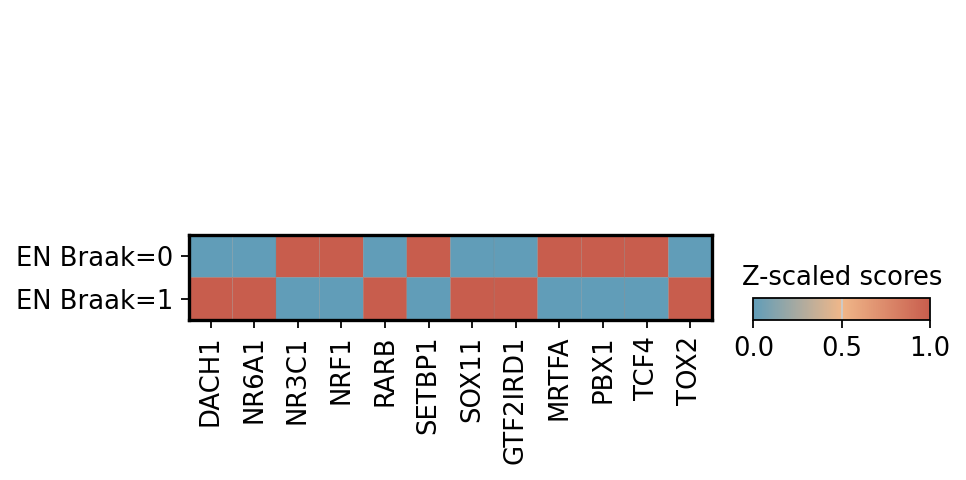

In [59]:
from matplotlib.colors import LinearSegmentedColormap

source_markers = {}
source_markers['EN_0.0'] = ['NR6A1', 'NR3C1','NRF1', 'RARB', 'SETBP1 ', 'SOX11']
source_markers['EN_0.6'] = ['NR6A1', 'NR3C1', 'SOX11']

# Define the colors
colors = ['#619DB8', '#F0B789', '#C85D4D']

# Create custom colormap
cmap_J = LinearSegmentedColormap.from_list("custom_cmap", colors)
# /depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Code/figures/
sc.pl.matrixplot(
    adata=score,
    var_names=['DACH1', 'NR6A1', 'NR3C1','NRF1', 'RARB', 'SETBP1', 'SOX11', 'GTF2IRD1', 'MRTFA', 'PBX1', 'TCF4', 'TOX2'],
    groupby="condition_celltype",
    dendrogram=False,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap=cmap_J,
    #save='EN_tf_0_6.png'
    #save='EN_tf_0_5.png'
    #save='EN_tf_0_4.png'
    #save='EN_tf_0_3.png'
    #save='EN_tf_0_2.png'
    save='EN_tf_0_1.png'
)

In [13]:
df.to_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_6_t-test_overestim_var.xlsx')
acts.obsm['ulm_estimate'].to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_6_ulm_output.csv')

# GENIE3

In [2]:
# load GENIE3 function

def compute_feature_importances(estimator):
    if isinstance(estimator, BaseDecisionTree):
        return estimator.tree_.compute_feature_importances(normalize=False)
    else:
        importances = [e.tree_.compute_feature_importances(normalize=False)
                       for e in estimator.estimators_]
        importances = array(importances)
        return sum(importances,axis=0) / len(estimator)
        


def get_link_list(VIM,gene_names=None,regulators='all',maxcount='all',file_name=None):
    
    """Gets the ranked list of (directed) regulatory links.
    
    Parameters
    ----------
    
    VIM: numpy array
        Array as returned by the function GENIE3(), in which the element (i,j) is the score of the edge directed from the i-th gene to the j-th gene. 
        
    gene_names: list of strings, optional
        List of length p, where p is the number of rows/columns in VIM, containing the names of the genes. The i-th item of gene_names must correspond to the i-th row/column of VIM. When the gene names are not provided, the i-th gene is named Gi.
        default: None
        
    regulators: list of strings, optional
        List containing the names of the candidate regulators. When a list of regulators is provided, the names of all the genes must be provided (in gene_names), and the returned list contains only edges directed from the candidate regulators. When regulators is set to 'all', any gene can be a candidate regulator.
        default: 'all'
        
    maxcount: 'all' or positive integer, optional
        Writes only the first maxcount regulatory links of the ranked list. When maxcount is set to 'all', all the regulatory links are written.
        default: 'all'
        
    file_name: string, optional
        Writes the ranked list of regulatory links to the file file_name.
        default: None
        
        
    
    Returns
    -------
    
    The list of regulatory links, ordered according to the edge score. Auto-regulations do not appear in the list. Regulatory links with a score equal to zero are randomly permuted. In the ranked list of edges, each line has format:
        
        regulator   target gene     score of edge
    """
    
    # Check input arguments      
    if not isinstance(VIM,ndarray):
        raise ValueError('VIM must be a square array')
    elif VIM.shape[0] != VIM.shape[1]:
        raise ValueError('VIM must be a square array')
        
    ngenes = VIM.shape[0]
        
    if gene_names is not None:
        if not isinstance(gene_names,(list,tuple)):
            raise ValueError('input argument gene_names must be a list of gene names')
        elif len(gene_names) != ngenes:
            raise ValueError('input argument gene_names must be a list of length p, where p is the number of columns/genes in the expression data')
        
    if regulators != 'all':
        if not isinstance(regulators,(list,tuple)):
            raise ValueError('input argument regulators must be a list of gene names')

        if gene_names is None:
            raise ValueError('the gene names must be specified (in input argument gene_names)')
        else:
            sIntersection = set(gene_names).intersection(set(regulators))
            if not sIntersection:
                raise ValueError('The genes must contain at least one candidate regulator')
        
    if maxcount != 'all' and not isinstance(maxcount,int):
        raise ValueError('input argument maxcount must be "all" or a positive integer')
        
    if file_name is not None and not isinstance(file_name,str):
        raise ValueError('input argument file_name must be a string')
    
    

    # Get the indices of the candidate regulators
    if regulators == 'all':
        input_idx = range(ngenes)
    else:
        input_idx = [i for i, gene in enumerate(gene_names) if gene in regulators]
    
    # Get the non-ranked list of regulatory links
    vInter = [(i,j,score) for (i,j),score in ndenumerate(VIM) if i in input_idx and i!=j]
    
    # Rank the list according to the weights of the edges        
    vInter_sort = sorted(vInter,key=itemgetter(2),reverse=True)
    nInter = len(vInter_sort)
    
    # Random permutation of edges with score equal to 0
    flag = 1
    i = 0
    while flag and i < nInter:
        (TF_idx,target_idx,score) = vInter_sort[i]
        if score == 0:
            flag = 0
        else:
            i += 1
            
    if not flag:
        items_perm = vInter_sort[i:]
        items_perm = random.permutation(items_perm)
        vInter_sort[i:] = items_perm
        
    # Write the ranked list of edges
    nToWrite = nInter
    if isinstance(maxcount,int) and maxcount >= 0 and maxcount < nInter:
        nToWrite = maxcount
        
    if file_name:
    
        outfile = open(file_name,'w')
    
        if gene_names is not None:
            for i in range(nToWrite):
                (TF_idx,target_idx,score) = vInter_sort[i]
                TF_idx = int(TF_idx)
                target_idx = int(target_idx)
                outfile.write('%s\t%s\t%.6f\n' % (gene_names[TF_idx],gene_names[target_idx],score))
        else:
            for i in range(nToWrite):
                (TF_idx,target_idx,score) = vInter_sort[i]
                TF_idx = int(TF_idx)
                target_idx = int(target_idx)
                outfile.write('G%d\tG%d\t%.6f\n' % (TF_idx+1,target_idx+1,score))
            
        
        outfile.close()
        
    else:
        
        if gene_names is not None:
            for i in range(nToWrite):
                (TF_idx,target_idx,score) = vInter_sort[i]
                TF_idx = int(TF_idx)
                target_idx = int(target_idx)
                print('%s\t%s\t%.6f' % (gene_names[TF_idx],gene_names[target_idx],score))
        else:
            for i in range(nToWrite):
                (TF_idx,target_idx,score) = vInter_sort[i]
                TF_idx = int(TF_idx)
                target_idx = int(target_idx)
                print('G%d\tG%d\t%.6f' % (TF_idx+1,target_idx+1,score))
                
                
                



def GENIE3(expr_data,gene_names=None,regulators='all',tree_method='RF',K='sqrt',ntrees=1000,nthreads=1):
    
    '''Computation of tree-based scores for all putative regulatory links.
    
    Parameters
    ----------
    
    expr_data: numpy array
        Array containing gene expression values. Each row corresponds to a condition and each column corresponds to a gene.
        
    gene_names: list of strings, optional
        List of length p, where p is the number of columns in expr_data, containing the names of the genes. The i-th item of gene_names must correspond to the i-th column of expr_data.
        default: None
        
    regulators: list of strings, optional
        List containing the names of the candidate regulators. When a list of regulators is provided, the names of all the genes must be provided (in gene_names). When regulators is set to 'all', any gene can be a candidate regulator.
        default: 'all'
        
    tree-method: 'RF' or 'ET', optional
        Specifies which tree-based procedure is used: either Random Forest ('RF') or Extra-Trees ('ET')
        default: 'RF'
        
    K: 'sqrt', 'all' or a positive integer, optional
        Specifies the number of selected attributes at each node of one tree: either the square root of the number of candidate regulators ('sqrt'), the total number of candidate regulators ('all'), or any positive integer.
        default: 'sqrt'
         
    ntrees: positive integer, optional
        Specifies the number of trees grown in an ensemble.
        default: 1000
    
    nthreads: positive integer, optional
        Number of threads used for parallel computing
        default: 1
        
        
    Returns
    -------

    An array in which the element (i,j) is the score of the edge directed from the i-th gene to the j-th gene. All diagonal elements are set to zero (auto-regulations are not considered). When a list of candidate regulators is provided, the scores of all the edges directed from a gene that is not a candidate regulator are set to zero.
        
    '''
    
    time_start = time.time()
    
    # Check input arguments
    if not isinstance(expr_data,ndarray):
        raise ValueError('expr_data must be an array in which each row corresponds to a condition/sample and each column corresponds to a gene')
        
    ngenes = expr_data.shape[1]
    
    if gene_names is not None:
        if not isinstance(gene_names,(list,tuple)):
            raise ValueError('input argument gene_names must be a list of gene names')
        elif len(gene_names) != ngenes:
            raise ValueError('input argument gene_names must be a list of length p, where p is the number of columns/genes in the expr_data')
        
    if regulators != 'all':
        if not isinstance(regulators,(list,tuple)):
            raise ValueError('input argument regulators must be a list of gene names')

        if gene_names is None:
            raise ValueError('the gene names must be specified (in input argument gene_names)')
        else:
            sIntersection = set(gene_names).intersection(set(regulators))
            if not sIntersection:
                raise ValueError('the genes must contain at least one candidate regulator')        
        
    if tree_method != 'RF' and tree_method != 'ET':
        raise ValueError('input argument tree_method must be "RF" (Random Forests) or "ET" (Extra-Trees)')
        
    if K != 'sqrt' and K != 'all' and not isinstance(K,int): 
        raise ValueError('input argument K must be "sqrt", "all" or a stricly positive integer')
        
    if isinstance(K,int) and K <= 0:
        raise ValueError('input argument K must be "sqrt", "all" or a stricly positive integer')
    
    if not isinstance(ntrees,int):
        raise ValueError('input argument ntrees must be a stricly positive integer')
    elif ntrees <= 0:
        raise ValueError('input argument ntrees must be a stricly positive integer')
        
    if not isinstance(nthreads,int):
        raise ValueError('input argument nthreads must be a stricly positive integer')
    elif nthreads <= 0:
        raise ValueError('input argument nthreads must be a stricly positive integer')
        
        
    print('Tree method: ' + str(tree_method))
    print('K: ' + str(K))
    print('Number of trees: ' + str(ntrees))
    print('\n')
        
    
    # Get the indices of the candidate regulators
    if regulators == 'all':
        input_idx = list(range(ngenes))
    else:
        input_idx = [i for i, gene in enumerate(gene_names) if gene in regulators]

    
    # Learn an ensemble of trees for each target gene, and compute scores for candidate regulators
    VIM = zeros((ngenes,ngenes))
    
    if nthreads > 1:
        print('running jobs on %d threads' % nthreads)

        input_data = list()
        for i in range(ngenes):
            input_data.append( [expr_data,i,input_idx,tree_method,K,ntrees] )

        pool = Pool(nthreads)
        alloutput = pool.map(wr_GENIE3_single, input_data)
    
        for (i,vi) in alloutput:
            VIM[i,:] = vi

    else:
        print('running single threaded jobs')
        for i in range(ngenes):
            print('Gene %d/%d...' % (i+1,ngenes))
            
            vi = GENIE3_single(expr_data,i,input_idx,tree_method,K,ntrees)
            VIM[i,:] = vi

   
    VIM = transpose(VIM)
 
    time_end = time.time()
    print("Elapsed time: %.2f seconds" % (time_end - time_start))

    return VIM
    
    
    
def wr_GENIE3_single(args):
    return([args[1], GENIE3_single(args[0], args[1], args[2], args[3], args[4], args[5])])
    


def GENIE3_single(expr_data,output_idx,input_idx,tree_method,K,ntrees):
    
    ngenes = expr_data.shape[1]
    
    # Expression of target gene
    output = expr_data[:,output_idx]
    
    # Normalize output data
    output = output / std(output)
    
    # Remove target gene from candidate regulators
    input_idx = input_idx[:]
    if output_idx in input_idx:
        input_idx.remove(output_idx)

    expr_data_input = expr_data[:,input_idx]
    
    # Parameter K of the tree-based method
    if (K == 'all') or (isinstance(K,int) and K >= len(input_idx)):
        max_features = "auto"
    else:
        max_features = K
    
    if tree_method == 'RF':
        treeEstimator = RandomForestRegressor(n_estimators=ntrees,max_features=max_features)
    elif tree_method == 'ET':
        treeEstimator = ExtraTreesRegressor(n_estimators=ntrees,max_features=max_features)

    # Learn ensemble of trees
    treeEstimator.fit(expr_data_input,output)
    
    # Compute importance scores
    feature_importances = compute_feature_importances(treeEstimator)
    vi = zeros(ngenes)
    vi[input_idx] = feature_importances
       
    return vi
        

In [3]:
# Read tf and flux sampling
#tf = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/TF_EN_merge.csv',index_col=0)

sampling = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/Flux_Sampling_01162025/EN_100sample.csv')
sampling = sampling.to_pandas()
sampling.set_index(sampling.columns[0], inplace=True)

core_rxn = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Code/ML_final_code/core_reaction_remove_allTrans.csv')
core_rxn = core_rxn['core_reaction_remove_allTrans'].to_list()

core_rxn = core_rxn + sampling.columns[-3:].to_list()
sampling = sampling[core_rxn]

In [4]:
NPS_AD_metadata = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/NPS-AD_neuropathology_and_diagnosis_metadata.csv')

#AD = []
#for i in tf.index:
#    sample_name = i
#    AD_class = NPS_AD_metadata[NPS_AD_metadata['IndividualID']==sample_name]['BRAAK_AD'].to_list()[0]
#    AD.append(AD_class)
    
#tf['BRAAK_AD'] = AD

## Top 100 Filtered reactiond ML -- group samples(Filtered_neuron_enriched TFs)

In [ ]:
# Load flux sampling data with significantly different reactions
sampling_0 = sampling[sampling['BRAAK_AD'].isin([0])]
sampling_1 = sampling[sampling['BRAAK_AD'].isin([1])]
sampling_2 = sampling[sampling['BRAAK_AD'].isin([2])]
sampling_3 = sampling[sampling['BRAAK_AD'].isin([3])]
sampling_4 = sampling[sampling['BRAAK_AD'].isin([4])]
sampling_5 = sampling[sampling['BRAAK_AD'].isin([5])]
sampling_6 = sampling[sampling['BRAAK_AD'].isin([6])]

EN_top50 = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100_noTrans/EN_avg_100_noTrans.xlsx', index_col=0)

sampling1_top50 = EN_top50['G0_G1'].to_list()
sampling2_top50 = EN_top50['G0_G2'].to_list()
sampling3_top50 = EN_top50['G0_G3'].to_list()
sampling4_top50 = EN_top50['G0_G4'].to_list()
sampling5_top50 = EN_top50['G0_G5'].to_list()
sampling6_top50 = EN_top50['G0_G6'].to_list()


sampling_1 = sampling_1[sampling1_top50]
sampling_2 = sampling_2[sampling2_top50]
sampling_3 = sampling_3[sampling3_top50]
sampling_4 = sampling_4[sampling4_top50]
sampling_5 = sampling_5[sampling5_top50]
sampling_6 = sampling_6[sampling6_top50]

In [6]:
group1_sampleID = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([1])]['IndividualID'].to_list()
group2_sampleID = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([2])]['IndividualID'].to_list()
group3_sampleID = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([3])]['IndividualID'].to_list()
group4_sampleID = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([4])]['IndividualID'].to_list()
group5_sampleID = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([5])]['IndividualID'].to_list()
group6_sampleID = NPS_AD_metadata[NPS_AD_metadata['BRAAK_AD'].isin([6])]['IndividualID'].to_list()


In [7]:
Filtered_TF = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/TF_counts_comparsion_EN_vs_restcells.xlsx', 'Filtered_tf')
Filtered_TF = Filtered_TF['TF'].to_list()


tf_1 = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_1_ulm_output.csv')
tf_1 = tf_1.to_pandas()
tf_1.set_index(tf_1.columns[0], inplace=True)
tf_1 = tf_1.loc[:, tf_1.columns.isin(Filtered_TF)]
tf_1["Sample_ID"] = [i.split("-")[0] for i in tf_1.index.to_list()]
tf_1 = tf_1[tf_1['Sample_ID'].isin(group1_sampleID)]
tf_1 = tf_1.groupby('Sample_ID').mean(numeric_only=True)
tf_1.index.name = ''

tf_2 = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_2_ulm_output.csv')
tf_2 = tf_2.to_pandas()
tf_2.set_index(tf_2.columns[0], inplace=True)
tf_2 = tf_2.loc[:, tf_2.columns.isin(Filtered_TF)]
tf_2["Sample_ID"] = [i.split("-")[0] for i in tf_2.index.to_list()]
tf_2 = tf_2[tf_2['Sample_ID'].isin(group2_sampleID)]
tf_2 = tf_2.groupby('Sample_ID').mean(numeric_only=True)
tf_2.index.name = ''

tf_3 = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_3_ulm_output.csv')
tf_3 = tf_3.to_pandas()
tf_3.set_index(tf_3.columns[0], inplace=True)
tf_3 = tf_3.loc[:, tf_3.columns.isin(Filtered_TF)]
tf_3["Sample_ID"] = [i.split("-")[0] for i in tf_3.index.to_list()]
tf_3 = tf_3[tf_3['Sample_ID'].isin(group3_sampleID)]
tf_3 = tf_3.groupby('Sample_ID').mean(numeric_only=True)
tf_3.index.name = ''

tf_4 = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_4_ulm_output.csv')
tf_4 = tf_4.to_pandas()
tf_4.set_index(tf_4.columns[0], inplace=True)
tf_4 = tf_4.loc[:, tf_4.columns.isin(Filtered_TF)]
tf_4["Sample_ID"] = [i.split("-")[0] for i in tf_4.index.to_list()]
tf_4 = tf_4[tf_4['Sample_ID'].isin(group4_sampleID)]
tf_4 = tf_4.groupby('Sample_ID').mean(numeric_only=True)
tf_4.index.name = ''

tf_5 = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_5_ulm_output.csv')
tf_5 = tf_5.to_pandas()
tf_5.set_index(tf_5.columns[0], inplace=True)
tf_5 = tf_5.loc[:, tf_5.columns.isin(Filtered_TF)]
tf_5["Sample_ID"] = [i.split("-")[0] for i in tf_5.index.to_list()]
tf_5 = tf_5[tf_5['Sample_ID'].isin(group5_sampleID)]
tf_5 = tf_5.groupby('Sample_ID').mean(numeric_only=True)
tf_5.index.name = ''

tf_6 = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_6_ulm_output.csv')
tf_6 = tf_6.to_pandas()
tf_6.set_index(tf_6.columns[0], inplace=True)
tf_6 = tf_6.loc[:, tf_6.columns.isin(Filtered_TF)]
tf_6["Sample_ID"] = [i.split("-")[0] for i in tf_6.index.to_list()]
tf_6 = tf_6[tf_6['Sample_ID'].isin(group6_sampleID)]
tf_6 = tf_6.groupby('Sample_ID').mean(numeric_only=True)
tf_6.index.name = ''


In [15]:
tf_6['BMAL2'].mean()

0.2740023510743454

In [9]:
tf_1.fillna(0, inplace=True)
tf_2.fillna(0, inplace=True)
tf_3.fillna(0, inplace=True)
tf_4.fillna(0, inplace=True)
tf_5.fillna(0, inplace=True)
tf_6.fillna(0, inplace=True)


tf_1 = tf_1.loc[:, tf_1.std() != 0]
tf_2 = tf_2.loc[:, tf_2.std() != 0]
tf_3 = tf_3.loc[:, tf_3.std() != 0]
tf_4 = tf_4.loc[:, tf_4.std() != 0]
tf_5 = tf_5.loc[:, tf_5.std() != 0]
tf_6 = tf_6.loc[:, tf_6.std() != 0]


sampling_1_sub = sampling_1.sample(n=tf_1.shape[0], random_state=42)  
sampling_2_sub = sampling_2.sample(n=tf_2.shape[0], random_state=42)  
sampling_3_sub = sampling_3.sample(n=tf_3.shape[0], random_state=42)  
sampling_4_sub = sampling_4.sample(n=tf_4.shape[0], random_state=42)  
sampling_5_sub = sampling_5.sample(n=tf_5.shape[0], random_state=42)  
sampling_6_sub = sampling_5.sample(n=tf_6.shape[0], random_state=42)  


sampling_1_sub.fillna(0, inplace=True)
sampling_2_sub.fillna(0, inplace=True)
sampling_3_sub.fillna(0, inplace=True)
sampling_4_sub.fillna(0, inplace=True)
sampling_5_sub.fillna(0, inplace=True)
sampling_6_sub.fillna(0, inplace=True)


sampling_1_sub = sampling_1_sub.loc[:, sampling_1_sub.std() != 0]
sampling_2_sub = sampling_2_sub.loc[:, sampling_2_sub.std() != 0]
sampling_3_sub = sampling_3_sub.loc[:, sampling_3_sub.std() != 0]
sampling_4_sub = sampling_4_sub.loc[:, sampling_4_sub.std() != 0]
sampling_5_sub = sampling_5_sub.loc[:, sampling_5_sub.std() != 0]
sampling_6_sub = sampling_6_sub.loc[:, sampling_6_sub.std() != 0]


tf_1.reset_index(drop=True, inplace=True)
tf_2.reset_index(drop=True, inplace=True)
tf_3.reset_index(drop=True, inplace=True)
tf_4.reset_index(drop=True, inplace=True)
tf_5.reset_index(drop=True, inplace=True)
tf_6.reset_index(drop=True, inplace=True)


sampling_1_sub.reset_index(drop=True, inplace=True)
sampling_2_sub.reset_index(drop=True, inplace=True)
sampling_3_sub.reset_index(drop=True, inplace=True)
sampling_4_sub.reset_index(drop=True, inplace=True)
sampling_5_sub.reset_index(drop=True, inplace=True)
sampling_6_sub.reset_index(drop=True, inplace=True) 


merged_df_1 = pd.concat([sampling_1_sub, tf_1], axis=1)
merged_df_2 = pd.concat([sampling_2_sub, tf_2], axis=1)
merged_df_3 = pd.concat([sampling_3_sub, tf_3], axis=1)
merged_df_4 = pd.concat([sampling_4_sub, tf_4], axis=1)
merged_df_5 = pd.concat([sampling_5_sub, tf_5], axis=1)
merged_df_6 = pd.concat([sampling_6_sub, tf_6], axis=1)

### Run Genie3

In [10]:
import pickle

for i in range(7):
    print(i)
    
    if i == 0:
        print(i)
        #df_flux = merged_df_0.values
        #VI = GENIE3(df_flux,gene_names=merged_df_0.columns.to_list(), regulators=tf_0.columns.to_list(),tree_method='RF',K='sqrt',ntrees=1000,nthreads=1)
        # VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN/VI' + str(i) + ".pkl"
        #print(VI_save_path)
        #with open(VI_save_path, 'wb') as f:
        #    pickle.dump(VI, f)
            
    elif i == 1:
        df_flux = merged_df_1.values
        VI = GENIE3(df_flux,gene_names=merged_df_1.columns.to_list(), regulators=tf_1.columns.to_list(),tree_method='RF',K='sqrt',ntrees=1000,nthreads=30)
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50_tf_group/VI' + str(i) + ".pkl"
        VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI' + str(i) + ".pkl"
        
        print(VI_save_path)
        with open(VI_save_path, 'wb') as f:
            pickle.dump(VI, f)

            
    elif i == 2:
        df_flux = merged_df_2.values
        VI = GENIE3(df_flux,gene_names=merged_df_2.columns.to_list(), regulators=tf_2.columns.to_list(),tree_method='RF',K='sqrt',ntrees=1000,nthreads=30)
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50_tf_group/VI' + str(i) + ".pkl"
        VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI' + str(i) + ".pkl"
        
        print(VI_save_path)
        with open(VI_save_path, 'wb') as f:
            pickle.dump(VI, f)
            
    elif i == 3:
        df_flux = merged_df_3.values
        VI = GENIE3(df_flux,gene_names=merged_df_3.columns.to_list(), regulators=tf_3.columns.to_list(),tree_method='RF',K='sqrt',ntrees=1000,nthreads=30)
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50_tf_group/VI' + str(i) + ".pkl"
        VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI' + str(i) + ".pkl"

        print(VI_save_path)
        with open(VI_save_path, 'wb') as f:
            pickle.dump(VI, f)
    
    elif i == 4:
        df_flux = merged_df_4.values
        VI = GENIE3(df_flux,gene_names=merged_df_4.columns.to_list(), regulators=tf_4.columns.to_list(),tree_method='RF',K='sqrt',ntrees=1000,nthreads=30)
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50_tf_group/VI' + str(i) + ".pkl"
        VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI' + str(i) + ".pkl"

        print(VI_save_path)
        with open(VI_save_path, 'wb') as f:
            pickle.dump(VI, f)
            
    
    elif i == 5:
        df_flux = merged_df_5.values
        VI = GENIE3(df_flux,gene_names=merged_df_5.columns.to_list(), regulators=tf_5.columns.to_list(),tree_method='RF',K='sqrt',ntrees=1000,nthreads=30)
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50_tf_group/VI' + str(i) + ".pkl"
        VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI' + str(i) + ".pkl"
       
        print(VI_save_path)
        with open(VI_save_path, 'wb') as f:
            pickle.dump(VI, f)
    
    elif i == 6:
        df_flux = merged_df_6.values
        VI = GENIE3(df_flux,gene_names=merged_df_6.columns.to_list(), regulators=tf_6.columns.to_list(),tree_method='RF',K='sqrt',ntrees=1000,nthreads=30)
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/VI' + str(i) + ".pkl"
        #VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50_tf_group/VI' + str(i) + ".pkl"
        VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI' + str(i) + ".pkl"
       
        print(VI_save_path)
        with open(VI_save_path, 'wb') as f:
            pickle.dump(VI, f)

        

0
0
1
Tree method: RF
K: sqrt
Number of trees: 1000


running jobs on 30 threads
Elapsed time: 15.61 seconds
/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI1.pkl
2
Tree method: RF
K: sqrt
Number of trees: 1000


running jobs on 30 threads
Elapsed time: 17.49 seconds
/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI2.pkl
3
Tree method: RF
K: sqrt
Number of trees: 1000


running jobs on 30 threads
Elapsed time: 17.58 seconds
/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI3.pkl
4
Tree method: RF
K: sqrt
Number of trees: 1000


running jobs on 30 threads
Elapsed time: 15.86 seconds
/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/VI4.pkl
5
Tree method: RF
K:

In [11]:
#VIM_files = os.listdir('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/')
VIM_files = os.listdir('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/')

VI_save_path = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/'


for i in VIM_files:
    print(i)
    read_path = VI_save_path + i
    file_name = i.split('.pkl')[0]
    with open(read_path, 'rb') as f:
        load_VI = pickle.load(f)
   
        
    if i == "VI0.pkl":
        gene_names = merged_df_0.columns.to_list()
        regulators=tf_0.columns.to_list()
        print(i)
        
    elif i == "VI1.pkl":
        gene_names = merged_df_1.columns.to_list()
        regulators=tf_1.columns.to_list()
        
    elif i == "VI2.pkl":
        gene_names = merged_df_2.columns.to_list()
        regulators=tf_2.columns.to_list()
        
    elif i == "VI3.pkl":
        gene_names = merged_df_3.columns.to_list()
        regulators=tf_3.columns.to_list()
        
    elif i == "VI4.pkl":
        gene_names = merged_df_4.columns.to_list()
        regulators=tf_4.columns.to_list()
        
    elif i == "VI5.pkl":
        gene_names = merged_df_5.columns.to_list()
        regulators=tf_5.columns.to_list()
        
    elif i == "VI6.pkl":
        gene_names = merged_df_6.columns.to_list()
        regulators=tf_6.columns.to_list()
        
    # save_file = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/' + file_name + '_links.txt'
    save_file = VI_save_path + file_name + '_links.txt'
    
    LINKS = get_link_list(load_VI,gene_names=gene_names,regulators=regulators,maxcount='all',file_name=save_file)






VI6.pkl
VI1.pkl
VI5.pkl
VI3.pkl
VI4.pkl
VI2.pkl


In [12]:
import networkx as nx
from networkx.readwrite import json_graph
import json

# files = os.listdir('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP50/')
folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/GENIE3/EN_TOP100_tf_group/'


files = os.listdir(folder)



for i in files:
    if i == 'VI0_links.txt':
        print(i)
        read_path = folder + i
        df = pd.read_csv(read_path, sep='\t', header=None, names=['regulator', 'target', 'weight'])
        network_df = df[~df['target'].isin(tf_0.columns.to_list())]
        network_df = network_df[network_df['regulator'].isin(tf_0.columns.to_list())]
        cyto_data_save_path = folder + 'EN_Cyto_0.json'
        hub_target_save_path = folder + 'hub_target_EN0.csv'
    elif i == 'VI1_links.txt':
        print(i)
        read_path = folder + i
        df = pd.read_csv(read_path, sep='\t', header=None, names=['regulator', 'target', 'weight'])
        network_df = df[~df['target'].isin(tf_1.columns.to_list())]
        network_df = network_df[network_df['regulator'].isin(tf_1.columns.to_list())]
        cyto_data_save_path = folder + 'EN_Cyto_1.json'
        hub_target_save_path = folder + 'hub_target_EN1.csv'
    elif i == 'VI2_links.txt':
        print(i)
        read_path = folder + i
        df = pd.read_csv(read_path, sep='\t', header=None, names=['regulator', 'target', 'weight'])
        network_df = df[~df['target'].isin(tf_2.columns.to_list())]
        network_df = network_df[network_df['regulator'].isin(tf_2.columns.to_list())]
        cyto_data_save_path = folder + 'EN_Cyto_2.json'
        hub_target_save_path = folder + 'hub_target_EN2.csv'
    elif i == 'VI3_links.txt':
        print(i)
        read_path = folder + i
        df = pd.read_csv(read_path, sep='\t', header=None, names=['regulator', 'target', 'weight'])
        network_df = df[~df['target'].isin(tf_3.columns.to_list())]
        network_df = network_df[network_df['regulator'].isin(tf_3.columns.to_list())]
        cyto_data_save_path = folder + 'EN_Cyto_3.json'
        hub_target_save_path = folder + 'hub_target_EN3.csv'
    elif i == 'VI4_links.txt':
        print(i)
        read_path = folder + i
        df = pd.read_csv(read_path, sep='\t', header=None, names=['regulator', 'target', 'weight'])
        network_df = df[~df['target'].isin(tf_4.columns.to_list())]
        network_df = network_df[network_df['regulator'].isin(tf_4.columns.to_list())]
        cyto_data_save_path = folder + 'EN_Cyto_4.json'
        hub_target_save_path = folder + 'hub_target_EN4.csv'
    elif i == 'VI5_links.txt':
        print(i)
        read_path = folder + i
        df = pd.read_csv(read_path, sep='\t', header=None, names=['regulator', 'target', 'weight'])
        network_df = df[~df['target'].isin(tf_5.columns.to_list())]
        network_df = network_df[network_df['regulator'].isin(tf_5.columns.to_list())]
        cyto_data_save_path = folder + 'EN_Cyto_5.json'
        hub_target_save_path = folder + 'hub_target_EN5.csv'
    elif i == 'VI6_links.txt':
        print(i)
        read_path = folder + i
        df = pd.read_csv(read_path, sep='\t', header=None, names=['regulator', 'target', 'weight'])
        network_df = df[~df['target'].isin(tf_6.columns.to_list())]
        network_df = network_df[network_df['regulator'].isin(tf_6.columns.to_list())]
        cyto_data_save_path = folder + 'EN_Cyto_6.json'
        hub_target_save_path = folder + 'hub_target_EN6.csv'
    
    else:
        continue
    
    
    
    
    #q_weight = np.quantile(network_df['weight'], q=0.999)
    q_weight = np.quantile(network_df['weight'], q=0.99)
    network_subset_df = network_df[network_df['weight'] > q_weight].copy()

    # Create a directed graph from the subsetted DataFrame
    net = nx.from_pandas_edgelist(
        network_subset_df,
        source='regulator',
        target='target',
        edge_attr='weight',
        create_using=nx.DiGraph()
    )

    cyto_data = json_graph.cytoscape_data(net)

    with open(cyto_data_save_path, 'w') as f:
        json.dump(cyto_data, f)

    # Identify "hub" regulator genes (using out-degree)
    degree = dict(net.out_degree())
    q_degree = np.quantile(list(degree.values()), q=0.90)
    degree_color = {gene: 'blue' if deg > q_degree else 'yellow' 
                    for gene, deg in degree.items()}
    hub_genes = [gene for gene, color in degree_color.items() if color == 'blue']

    # Get a list of the genes regulated by hub genes
    hub_target_df = (
        network_subset_df[network_subset_df['regulator'].isin(hub_genes)]
        .sort_values(['regulator', 'weight'], ascending=[True, False])
        .rename(columns={'regulator': 'regulator_hub'})
    )

    hub_target_df.to_csv(hub_target_save_path)

VI6_links.txt
VI1_links.txt
VI5_links.txt
VI4_links.txt
VI3_links.txt
VI2_links.txt


In [ ]:
tf_en = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/TF_EN_merge.csv', index_col=0)
tf_en

## Extract TF, Subsystems, Reactions, Genes and Metabolites

In [ ]:
from cobra.io import read_sbml_model_sbml_model, write_sbml_model,load_matlab_model

In [ ]:
os.environ['GUROBI_HOME'] = "/depot/pbaloni/data/Lab_members/Boyu_Jiang/Software/gurobi_license"
os.environ['GRB_LICENSE_FILE'] = "/depot/pbaloni/data/Lab_members/Boyu_Jiang/Software/gurobi_license/gurobi.lic"

In [ ]:
iNeuron = read_sbml_model('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Refinement/Final_reconstruction/ineuron_metabolome_01062025.xml')


In [ ]:
TF_res = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/NPS_AD_TFs_summary_top100_group_decoupler.xlsx', 'Correlation_EN')
TF_res = TF_res.iloc[4:]
TF_res



In [ ]:
group1 = TF_res.iloc[:, :5].reset_index(drop=True)
group1.columns = group1.iloc[0]
group1 = group1.drop(0).reset_index(drop=True)
group1 = group1[group1['pvalue'] < 0.05]

group2 = TF_res.iloc[:, 8:13].reset_index(drop=True)
group2.columns = group2.iloc[0]
group2 = group2.drop(0).reset_index(drop=True)
group2 = group2[group2['pvalue'] < 0.05]

group3 = TF_res.iloc[:, 16:21].reset_index(drop=True)
group3.columns = group3.iloc[0]
group3 = group3.drop(0).reset_index(drop=True)
group3 = group3[group3['pvalue'] < 0.05]

group4 = TF_res.iloc[:, 24:29].reset_index(drop=True)
group4.columns = group4.iloc[0]
group4 = group4.drop(0).reset_index(drop=True)
group4 = group4[group4['pvalue'] < 0.05]

group5 = TF_res.iloc[:, 32:37].reset_index(drop=True)
group5.columns = group5.iloc[0]
group5 = group5.drop(0).reset_index(drop=True)
group5 = group5[group5['pvalue'] < 0.05]

group6 = TF_res.iloc[:, 40:45].reset_index(drop=True)
group6.columns = group6.iloc[0]
group6 = group6.drop(0).reset_index(drop=True)
group6 = group6[group6['pvalue'] < 0.05]


early_stage = pd.concat([group1, group2], axis=0)
early_stage = early_stage.sort_values(by='Subsystem')
middle_stage = pd.concat([group3, group4], axis=0)
middle_stage = middle_stage.sort_values(by='Subsystem')
later_stage = pd.concat([group5, group6], axis=0)
later_stage = later_stage.sort_values(by='Subsystem')


In [ ]:
middle_stage

In [ ]:


reactions = []
genes = []
mets = []
TFs = []
subsystems = []
df = early_stage
for i in df['Reaction']:
    rxn = iNeuron.reactions.get_by_id(i)
    rxn_id = [i]
    gene_id = [i.name for i in rxn.genes]
    mets_id = [i.name for i in rxn.metabolites]
    
    max_len = maximum(len(gene_id), len(mets_id))
    rxn_id.extend([''] * (max_len - len(rxn_id)))
    gene_id.extend([''] * (max_len - len(gene_id)))
    mets_id.extend([''] * (max_len - len(mets_id)))
    
    reactions = reactions + rxn_id
    genes = genes + gene_id
    mets = mets + mets_id


for i in reactions:
    try:
        subsystem = df[df['Reaction'] == i]['Subsystem'].to_list()[0]
        TF = df[df['Reaction'] == i]['Transcriptional Factor'].to_list()[0]
        subsystems.append(subsystem) 
        TFs.append(TF)
    except:
        subsystems.append(subsystem) 
        TFs.append(TF)
        
df_save = pd.DataFrame({
    "Subsystem": subsystems,
    "Reaction" : reactions,
    "Gene": genes,
    "Metabolite": mets,
    "Transcriptional Factor": TFs,
})

df_save.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/Summzy_rxn_met_gene_tf/early_stage_EN.csv')

## Check epxression count of TFs

In [ ]:
adata = sc.read('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Data/TF_Decoupler.h5ad')
adata = adata[adata.obs['class'] == 'EN'].copy()


In [ ]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Annotate the group of mitochondrial genes as 'mt'
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Filter cells following standard QC criteria.
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

In [ ]:
adata.obs['barcode'] = adata.obs.index.to_list()
adata.obs

In [ ]:
NPS_AD_metadata = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/NPS-AD_neuropathology_and_diagnosis_metadata.csv')
NPS_AD_metadata = NPS_AD_metadata.rename(columns = {'IndividualID': 'Individual_ID'})
NPS_AD_metadata = NPS_AD_metadata[['Individual_ID', 'BRAAK_AD']]
NPS_AD_metadata['BRAAK_AD'] = NPS_AD_metadata['BRAAK_AD'].astype('category')
NPS_AD_metadata

In [ ]:
merged_meta = pd.merge(adata.obs, NPS_AD_metadata, on='Individual_ID', how='left')
adata.obs['BRAAK_AD'] = merged_meta['BRAAK_AD'].to_list()


In [ ]:
avg_expr = pd.DataFrame(index=adata.var_names)
for group in range(7):
    cells_in_group = adata.obs['BRAAK_AD'] == group
    mean_expr = adata[cells_in_group].X.mean(axis=0)
    mean_expr_flat = np.asarray(mean_expr).ravel()  # Flatten it to a 1D array

    # Assign the result to the avg_expr DataFrame
    avg_expr['Braak_' + str(group)] = mean_expr_flat

In [ ]:
avg_expr

In [ ]:
avg_expr.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/EN_avg_TFs.csv')

# Check ROC of TF AD classification

In [ ]:
import os
import pickle
import pandas as pd
import numpy as np
from numpy.random import default_rng
import pyarrow.csv as pv
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, precision_recall_curve, average_precision_score, roc_auc_score, classification_report
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import optuna
import shap
#import shapash

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
NPS_AD_metadata = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/NPS-AD_neuropathology_and_diagnosis_metadata.csv')
NPS_AD_metadata = NPS_AD_metadata[['IndividualID', 'BRAAK_AD']]
NPS_AD_metadata.set_index(NPS_AD_metadata.columns[0], inplace=True)
NPS_AD_metadata.index.name = ''
NPS_AD_metadata

In [ ]:
tf_0_1 = tf_0_1.join(NPS_AD_metadata, how='left')
tf_0_1

In [ ]:
tf_0_1 = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_1_ulm_output.xlsx', index_col=0)
tf_0_1["Sample_ID"] = [i.split("-")[0] for i in tf_0_1.index.to_list()]
#tf_1 = tf_1[tf_1['Sample_ID'].isin(group1_sampleID)]
tf_0_1 = tf_0_1.groupby('Sample_ID').mean(numeric_only=True)
tf_0_1.index.name = ''
tf_0_1

In [ ]:
tf_0_1 = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_1_ulm_output.xlsx', index_col=0)
tf_0_1["Sample_ID"] = [i.split("-")[0] for i in tf_0_1.index.to_list()]
tf_0_1 = tf_0_1.groupby('Sample_ID').mean(numeric_only=True)
tf_0_1.index.name = ''
tf_0_1 = tf_0_1.join(NPS_AD_metadata, how='left')
tf_0_1['BRAAK_AD'] = (tf_0_1['BRAAK_AD'] != 0).astype(int)

tf_0_2 = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_2_ulm_output.xlsx', index_col=0)
tf_0_2["Sample_ID"] = [i.split("-")[0] for i in tf_0_2.index.to_list()]
tf_0_2 = tf_0_2.groupby('Sample_ID').mean(numeric_only=True)
tf_0_2.index.name = ''
tf_0_2 = tf_0_2.join(NPS_AD_metadata, how='left')
tf_0_2['BRAAK_AD'] = (tf_0_2['BRAAK_AD'] != 0).astype(int)

tf_0_3 = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_3_ulm_output.xlsx', index_col=0)
tf_0_3["Sample_ID"] = [i.split("-")[0] for i in tf_0_3.index.to_list()]
tf_0_3 = tf_0_3.groupby('Sample_ID').mean(numeric_only=True)
tf_0_3.index.name = ''
tf_0_3 = tf_0_3.join(NPS_AD_metadata, how='left')
tf_0_3['BRAAK_AD'] = (tf_0_3['BRAAK_AD'] != 0).astype(int)


tf_0_4 = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_4_ulm_output.xlsx', index_col=0)
tf_0_4["Sample_ID"] = [i.split("-")[0] for i in tf_0_4.index.to_list()]
tf_0_4 = tf_0_4.groupby('Sample_ID').mean(numeric_only=True)
tf_0_4.index.name = ''
tf_0_4 = tf_0_4.join(NPS_AD_metadata, how='left')
tf_0_4['BRAAK_AD'] = (tf_0_4['BRAAK_AD'] != 0).astype(int)


tf_0_5 = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_5_ulm_output.xlsx', index_col=0)
tf_0_5["Sample_ID"] = [i.split("-")[0] for i in tf_0_5.index.to_list()]
tf_0_5 = tf_0_5.groupby('Sample_ID').mean(numeric_only=True)
tf_0_5.index.name = ''
tf_0_5 = tf_0_5.join(NPS_AD_metadata, how='left')
tf_0_5['BRAAK_AD'] = (tf_0_5['BRAAK_AD'] != 0).astype(int)


tf_0_6 = pd.read_excel('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/TF/decoupler_group_outputs/TF_EN_0_6_ulm_output.xlsx', index_col=0)
tf_0_6["Sample_ID"] = [i.split("-")[0] for i in tf_0_6.index.to_list()]
tf_0_6 = tf_0_6.groupby('Sample_ID').mean(numeric_only=True)
tf_0_6.index.name = ''
tf_0_6 = tf_0_6.join(NPS_AD_metadata, how='left')
tf_0_6['BRAAK_AD'] = (tf_0_6['BRAAK_AD'] != 0).astype(int)


In [ ]:
print('TF_0_1')
print(tf_0_1['BRAAK_AD'].value_counts())

print('TF_0_2')
print(tf_0_2['BRAAK_AD'].value_counts())

print('TF_0_3')
print(tf_0_3['BRAAK_AD'].value_counts())

print('TF_0_4')
print(tf_0_4['BRAAK_AD'].value_counts())

print('TF_0_5')
print(tf_0_5['BRAAK_AD'].value_counts())

print('TF_0_6')
print(tf_0_5['BRAAK_AD'].value_counts())


In [ ]:
TF = tf_0_6

feature_columns = TF.columns.to_list()[:TF.shape[1]-1]
# define tag column
target_column = 'BRAAK_AD'

X = TF[feature_columns]
y = TF[target_column]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=feature_columns)
# Split the data into training and test sets(8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100, stratify=y, shuffle=True)

#dtrain = xgb.DMatrix(data=X_train, label=y_train, feature_names=X_train.columns.to_list())
#dtest = xgb.DMatrix(data=X_test, label=y_test, feature_names=X_test.columns.to_list())

In [ ]:
def hyperopt_objective(params):

    params['objective'] = 'binary:logistic'
    params['eval_metric'] = 'logloss'
  
    
    evallist = [(X_train, y_train), X_test, y_test]
        
    # Train the model with early stopping based on validation data
    model = xgb.XGBClassifier(
        n_estimators = int(params['n_estimators']),
        max_depth = int(params['max_depth']),
        eta = params['eta'],
        gamma = params['gamma'],
        subsample = params['subsample'],
        colsample_bytree = params['colsample_bytree'],
        reg_lambda = params['lambda'],
        reg_alpha = params['alpha'],
        early_stopping_rounds=int(params['n_estimators'])*0.1,
        eval_metric = 'logloss',
        #scale_pos_weight = params['scale_pos_weight'],
        max_delta_step = params['max_delta_step'],
        n_jobs = -1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        
        verbose=False)
    
    # Get predictions on the validation set and compute AUC
    
    y_pred = model.predict(X_test)

  
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    #auc = roc_auc_score(y_test, y_pred_prob)  # Calculate ROC AUC for validation set
        
   
    
    # Return the negative of the average AUC score across all folds
   
    return {'loss': -accuracy, 'status': STATUS_OK}


from hyperopt.pyll.base import scope

params_space = {
            'gamma': hp.loguniform('gamma', np.log(0.0001), np.log(3)) - 0.0001,
            'max_depth': scope.int(hp.uniform('max_depth', 1, 4)),
            'subsample': hp.uniform('subsample', 0.5, 0.8),
            'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.7),
            'colsample_bylevel': hp.uniform('colsample_bylevel', 0.5, 0.7),
            'lambda': hp.loguniform('lambda', np.log(1), np.log(4)),
            'alpha': hp.loguniform('alpha', np.log(0.8), np.log(1)) - 0.0001,
            'eta': hp.loguniform('eta', np.log(0.3), np.log(0.5)),
            #'scale_pos_weight': hp.uniform('scale_pos_weight',1.2,1.3),
            #'scale_pos_weight': hp.uniform('scale_pos_weight',0.4,0.6),
            'max_delta_step':hp.uniform('max_delta_step', 0, 5),
            'n_estimators': hp.randint('n_estimators', 500, 1000)
            
                     }


trials = Trials()

rng = default_rng(123)

best = fmin(
    hyperopt_objective,         # The objective function to minimize
    space=params_space,         # The hyperparameter search space
    algo=tpe.suggest,           # The algorithm for optimization
    max_evals=50,                # Number of trials to evaluate
    trials=trials,              # Store the results of each trial
    rstate=rng                  # Random state for reproducibility
)

In [ ]:
# xbgclassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score,precision_recall_curve, auc
# Prepare the StratifiedKFold
Stratified_kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Create empty lists to store metrics
results = []
fold_num = 0

# Loop through each fold for cross-validation
for train_index, test_index in Stratified_kf.split(X, y):
    fold_num += 1
    X_val_train, X_val_test = X.iloc[train_index], X.iloc[test_index]
    y_val_train, y_val_test = y[train_index], y[test_index]
    

    
    # Train the model using xgb.train
    final_model = xgb.XGBClassifier(
        n_estimators = int(best['n_estimators']),
        max_depth = int(best['max_depth']),
        eta = best['eta'],
        gamma = best['gamma'],
        subsample = best['subsample'],
        colsample_bytree = best['colsample_bytree'],
        reg_lambda = best['lambda'],
        reg_alpha = best['alpha'],
        early_stopping_rounds=int(best['n_estimators'])*0.1,
        eval_metric = 'logloss',
        #scale_pos_weight = best['scale_pos_weight'],
        max_delta_step = best['max_delta_step'],
        n_jobs = -1
        
    )
    

    final_model.fit(X_val_train, y_val_train,
                   eval_set=[(X_val_test, y_val_test)],
                   verbose=False)
    
    # Make predictions
    y_pred = final_model.predict(X_val_test)
    y_pre_prob = final_model.predict_proba(X_val_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    recall = recall_score(y_val_test, y_pred)
    precision = precision_score(y_val_test, y_pred)
    precision_values, recall_values, _ = precision_recall_curve(y_val_test, y_pre_prob)
    pr_auc = auc(recall_values, precision_values)
    roc_auc = roc_auc_score(y_val_test, y_pre_prob)
    
    # Store results for each fold
    results.append({
        "Fold": fold_num,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision,
        "Precision-Recall AUC": pr_auc,
        "AUC (ROC Curve)": roc_auc

    })

# Create a DataFrame from the results of each fold
results_df = pd.DataFrame(results)

# Calculate average results across all folds
average_results = {
    "Fold": 'Average',
    "Accuracy": results_df['Accuracy'].mean(),
    "F1-score": results_df['F1-score'].mean(),
    "Recall": results_df['Recall'].mean(),
    "Precision": results_df['Precision'].mean(),
    "Precision-Recall AUC": results_df['Precision-Recall AUC'].mean(),
    "AUC (ROC Curve)": results_df['AUC (ROC Curve)'].mean()
}

# Add the average results to the DataFrame
average_df = pd.DataFrame([average_results])
results_df = pd.concat([results_df, average_df], ignore_index=True)

# Display the final results
results_df